# 06 — SHAP Explainability & Transfer Analysis (v2)
**Changes from v1:**
- Feature names updated to match v2 engineering (`FG_Level` instead of `FG_Index`, new lag/interaction features)
- H3 SVI test now works correctly — v1 had zero SVI features in the S&P 500 model, making the test meaningless
- SHAP attribution uses the richer feature set, so degradation attribution is more informative
- Common-feature set for transfer is larger due to expanded pool

Reads from `data/features/`, `data/selected/`, `data/results/` — writes to `data/results/`, `data/plots/`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

import subprocess, sys
for pkg in ['xgboost','shap']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'], capture_output=True)

import xgboost as xgb
import shap
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score, f1_score, accuracy_score, matthews_corrcoef
from scipy import stats

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

FEATURES = CFG['PATHS']['features']
SELECTED = CFG['PATHS']['selected']
RESULTS  = CFG['PATHS']['results']
PLOTS    = CFG['PATHS']['plots']
SEED     = CFG['SEED']
ALPHA    = CFG['ALPHA']
np.random.seed(SEED)

import os
os.makedirs(RESULTS, exist_ok=True)

sp500 = pd.read_csv(f'{FEATURES}/sp500_features.csv', index_col='Date', parse_dates=['Date'])
nifty = pd.read_csv(f'{FEATURES}/nifty_features.csv', index_col='Date', parse_dates=['Date'])
sp500.index = sp500.index.tz_localize(None)
nifty.index = nifty.index.tz_localize(None)

with open(f'{SELECTED}/selected_features.json') as f:
    SEL = json.load(f)

selected_sp500    = SEL['selected_sp500']
selected_nifty    = SEL['selected_nifty']
FAMILIES          = SEL['feature_families']
NIFTY_ONLY        = CFG.get('NIFTY_EXTRA_FEATURES',
                             ['USDINR_Ret','SP500_t1_Ret','FG_t1_Level','FG_t1_Delta'])
TARGET            = SEL['target_column']

def load_windows(path, feat_df):
    with open(path) as f:
        raw = json.load(f)
    out = []
    for w in raw:
        tr = feat_df.index[(feat_df.index >= w['train_start']) & (feat_df.index <= w['train_end'])]
        va = feat_df.index[(feat_df.index >= w['val_start'])   & (feat_df.index <= w['val_end'])]
        te = feat_df.index[(feat_df.index >= w['test_start'])  & (feat_df.index <= w['test_end'])]
        if len(tr) > 0 and len(va) > 0 and len(te) > 0:
            out.append((tr, va, te))
    return out

windows_sp500 = load_windows(f'{SELECTED}/windows_sp500.json', sp500)
windows_nifty = load_windows(f'{SELECTED}/windows_nifty.json', nifty)

print(f'S&P 500 features : {selected_sp500}')
print(f'NIFTY 50 features: {selected_nifty}')

Mounted at /content/drive
S&P 500 features : ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_2', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Level', 'FG_Delta', 'FG_Zone', 'FG_MA5', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']
NIFTY 50 features: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'Ret_Mean_10', 'Ret_Mean_20', 'Ret_Std_5', 'Ret_Std_10', 'RSI_14', 'RSI_5', 'MACD_Signal', 'MACD_Hist', 'ATR_14', 'Above_MA50', 'Price_MA50', 'VIX_Change', 'VIX_Level', 'VIX_Regime', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'FG_Extreme', 'SVI_Market', 'SVI_Index', 'SVI_Mom', 'FG_x_SVI', 'Vol_Adj_Ret', 'VIX_x_Spread', 'USDINR_Ret', 'SP500_t1_Ret', 'FG_t1_Level', 'FG_t1_Delta']


In [2]:
# Train final XGBoost on each market's largest training window.
# Largest = last walk-forward window, which has the most training data.

def train_final_xgb(feat_df, feature_cols, windows, label):
    tr_idx, _, te_idx = windows[-1]
    avail  = [f for f in feature_cols if f in feat_df.columns]
    X_tr   = feat_df.loc[tr_idx, avail].fillna(0)
    y_tr   = feat_df.loc[tr_idx, TARGET]
    X_te   = feat_df.loc[te_idx, avail].fillna(0)
    y_te   = feat_df.loc[te_idx, TARGET]

    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        eval_metric='logloss', random_state=SEED, verbosity=0
    )
    model.fit(X_tr, y_tr)

    if len(np.unique(y_te)) > 1:
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
        print(f'  {label}: {len(X_tr)} training days, test AUC = {auc:.4f}')
    else:
        print(f'  {label}: {len(X_tr)} training days (test window has one class only)')

    return model, X_te, y_te, avail

print('Training final XGBoost models for SHAP...')
xgb_sp500, X_test_sp500, y_test_sp500, feats_sp500 = train_final_xgb(
    sp500, selected_sp500, windows_sp500, 'S&P 500')
xgb_nifty, X_test_nifty, y_test_nifty, feats_nifty = train_final_xgb(
    nifty, selected_nifty, windows_nifty, 'NIFTY 50')

Training final XGBoost models for SHAP...
  S&P 500: 2139 training days, test AUC = 0.4858
  NIFTY 50: 2092 training days, test AUC = 0.4444


In [3]:
# Compute SHAP values using TreeExplainer

print('Computing SHAP values...')
exp_sp500      = shap.TreeExplainer(xgb_sp500)
shap_vals_sp500 = exp_sp500.shap_values(X_test_sp500[feats_sp500])
print('  S&P 500 done.')

exp_nifty      = shap.TreeExplainer(xgb_nifty)
shap_vals_nifty = exp_nifty.shap_values(X_test_nifty[feats_nifty])
print('  NIFTY 50 done.')

# Mean absolute SHAP — feature importance ranking
shap_mean_sp500 = pd.Series(
    np.abs(shap_vals_sp500).mean(axis=0), index=feats_sp500
).sort_values(ascending=False)

shap_mean_nifty = pd.Series(
    np.abs(shap_vals_nifty).mean(axis=0), index=feats_nifty
).sort_values(ascending=False)

print('\nTop features by mean |SHAP| — S&P 500:')
for feat, val in shap_mean_sp500.head(10).items():
    bar = '#' * int(val * 300)
    print(f'  {feat:22}  {val:.5f}  {bar}')

print('\nTop features by mean |SHAP| — NIFTY 50:')
for feat, val in shap_mean_nifty.head(10).items():
    bar = '#' * int(val * 300)
    print(f'  {feat:22}  {val:.5f}  {bar}')

Computing SHAP values...
  S&P 500 done.
  NIFTY 50 done.

Top features by mean |SHAP| — S&P 500:
  VIX_Level               0.18478  #######################################################
  Ret_Mean_5              0.11522  ##################################
  RSI_5                   0.10786  ################################
  Gold_Oil_Ratio          0.09963  #############################
  Log_Ret_2               0.09850  #############################
  Log_Ret_t               0.09806  #############################
  Log_Ret_1               0.09685  #############################
  Gold_Ret                0.09341  ############################
  Log_Ret_5               0.07661  ######################
  SVI_Index               0.05799  #################

Top features by mean |SHAP| — NIFTY 50:
  VIX_Change              0.26572  ###############################################################################
  SVI_Index               0.15229  #############################################
 

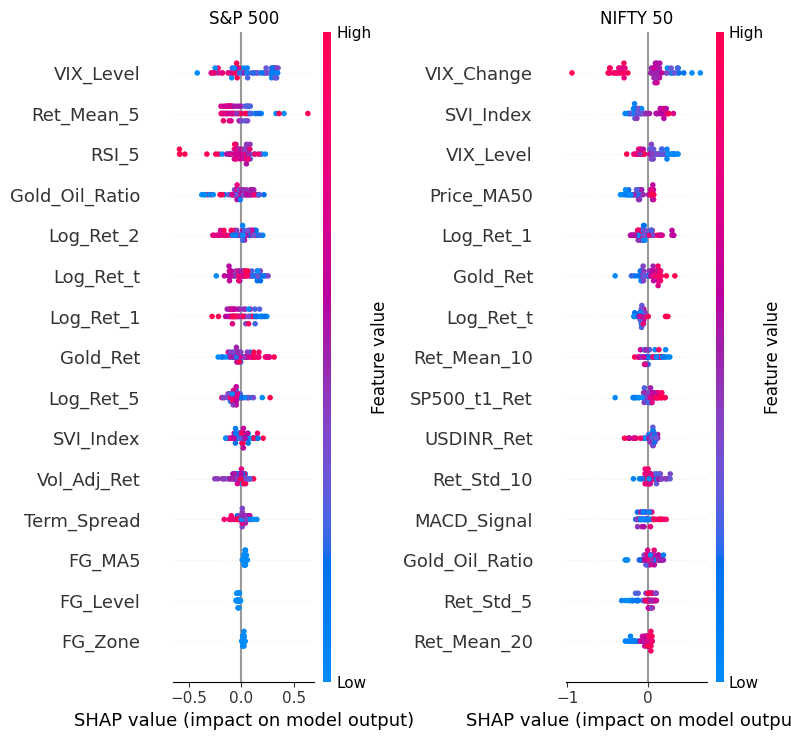

In [4]:
# SHAP beeswarm plots

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, shap_vals, X_test, feats, label in [
    (axes[0], shap_vals_sp500, X_test_sp500, feats_sp500, 'S&P 500'),
    (axes[1], shap_vals_nifty, X_test_nifty, feats_nifty, 'NIFTY 50'),
]:
    plt.sca(ax)
    shap.summary_plot(
        shap_vals,
        X_test[feats],
        feature_names=feats,
        show=False,
        plot_type='dot',
        max_display=min(15, len(feats)),
        color_bar_label='Feature value'
    )
    ax.set_title(label, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/06_shap_beeswarm_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# H3 test: is SVI importance higher in NIFTY 50 than S&P 500?
#
# SVI features in v2: SVI_Market, SVI_Index, SVI_Mom
# In v1 this test was broken because S&P 500 had zero SVI features selected.
# With the richer feature pool and relaxed LASSO, SVI should appear in both.

SVI_FEATURES = [f for f in ['SVI_Market','SVI_Index','SVI_Mom']
                if f in feats_sp500 or f in feats_nifty]

def shap_for_subset(shap_vals, feat_names, target_feats):
    idx = [i for i, f in enumerate(feat_names) if f in target_feats]
    if not idx:
        return np.array([])
    return np.abs(shap_vals[:, idx]).mean(axis=1)

svi_shap_sp500 = shap_for_subset(shap_vals_sp500, feats_sp500, SVI_FEATURES)
svi_shap_nifty = shap_for_subset(shap_vals_nifty, feats_nifty, SVI_FEATURES)

print(f'SVI features tested: {SVI_FEATURES}')
print(f'Observations: S&P 500 = {len(svi_shap_sp500)},  NIFTY 50 = {len(svi_shap_nifty)}')

h3_result = {}

if len(svi_shap_sp500) > 0 and len(svi_shap_nifty) > 0:
    t, p_two = stats.ttest_ind(svi_shap_nifty, svi_shap_sp500, equal_var=False)
    p_one    = p_two / 2 if t > 0 else 1 - p_two / 2

    print(f'\nH3 TEST — SVI importance: NIFTY 50 vs S&P 500')
    print(f'  Mean |SHAP| SVI — S&P 500  : {svi_shap_sp500.mean():.6f}')
    print(f'  Mean |SHAP| SVI — NIFTY 50 : {svi_shap_nifty.mean():.6f}')
    print(f'  t = {t:.3f}   p (one-tail) = {p_one:.4f}')
    print(f'  Reject H0: {p_one < ALPHA}')

    # Spearman rank correlation between importance rankings
    common = list(set(feats_sp500) & set(feats_nifty))
    if len(common) >= 3:
        rank_sp = shap_mean_sp500.reindex(common).rank(ascending=False)
        rank_ni = shap_mean_nifty.reindex(common).rank(ascending=False)
        sp_r, sp_p = stats.spearmanr(rank_sp, rank_ni)
        print(f'  Spearman rank r = {sp_r:.3f}  p = {sp_p:.4f}')
        if   sp_r < 0.4:  print('  Interpretation: high divergence between markets')
        elif sp_r < 0.65: print('  Interpretation: moderate divergence between markets')
        else:             print('  Interpretation: low divergence — similar importance rankings')
    else:
        sp_r = None

    h3_result = {
        'Mean_SVI_SHAP_SP500': round(float(svi_shap_sp500.mean()), 6),
        'Mean_SVI_SHAP_NIFTY': round(float(svi_shap_nifty.mean()), 6),
        't_stat'             : round(float(t), 4),
        'p_one_tail'         : round(float(p_one), 4),
        'Reject_H0'          : bool(p_one < ALPHA),
        'Spearman_r'         : round(float(sp_r), 3) if sp_r is not None else None,
    }
else:
    print('WARNING: SVI features missing from one or both markets.')
    print('Check that notebook 03 and 04 v2 were run before this notebook.')

SVI features tested: ['SVI_Market', 'SVI_Index', 'SVI_Mom']
Observations: S&P 500 = 64,  NIFTY 50 = 63

H3 TEST — SVI importance: NIFTY 50 vs S&P 500
  Mean |SHAP| SVI — S&P 500  : 0.057993
  Mean |SHAP| SVI — NIFTY 50 : 0.092430
  t = 4.358   p (one-tail) = 0.0000
  Reject H0: True
  Spearman rank r = 0.732  p = 0.0019
  Interpretation: low divergence — similar importance rankings


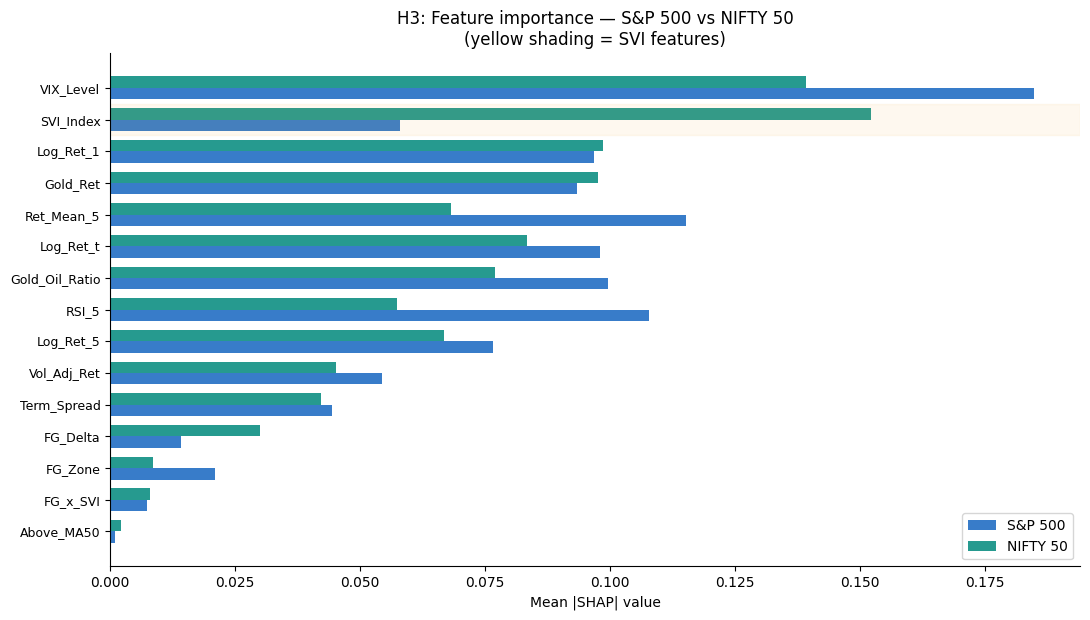

In [6]:
# Feature importance comparison chart — S&P 500 vs NIFTY 50 side by side

common_feats = list(set(feats_sp500) & set(feats_nifty))

if common_feats:
    # Sort by combined importance
    combined = (
        shap_mean_sp500.reindex(common_feats).fillna(0) +
        shap_mean_nifty.reindex(common_feats).fillna(0)
    ).sort_values(ascending=True)
    ordered = combined.index.tolist()

    fig, ax = plt.subplots(figsize=(11, max(5, len(ordered) * 0.42)))
    y      = np.arange(len(ordered))
    sp_val = shap_mean_sp500.reindex(ordered).fillna(0)
    ni_val = shap_mean_nifty.reindex(ordered).fillna(0)
    width  = 0.36

    ax.barh(y - width/2, sp_val, width, label='S&P 500', color='#1565c0', alpha=0.85)
    ax.barh(y + width/2, ni_val, width, label='NIFTY 50', color='#00897b', alpha=0.85)

    # Highlight SVI features
    for j, feat in enumerate(ordered):
        if feat in SVI_FEATURES:
            ax.axhspan(j - 0.48, j + 0.48, alpha=0.07, color='#f9a825')

    ax.set_yticks(y)
    ax.set_yticklabels(ordered, fontsize=9)
    ax.set_xlabel('Mean |SHAP| value')
    ax.set_title('H3: Feature importance — S&P 500 vs NIFTY 50\n'
                 '(yellow shading = SVI features)')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{PLOTS}/06_shap_divergence_v2.png', dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
# -----------------------------------------------------------------------
# Transfer Degradation Analysis (H4)
#
# Protocol:
#   Train on source market → test locally (F1_local)
#   Apply same model zero-shot to target market (F1_transfer)
#   Transfer Loss Lambda = F1_local - F1_transfer
#   Run in both directions.
#
# Common features: features present in both markets' selected sets,
# excluding NIFTY-only cross-market lag features (SP500_t1_Ret etc.)
# because those are definitionally unavailable in the S&P 500 context.
# -----------------------------------------------------------------------

def score_metrics(model, X, y):
    if len(np.unique(y)) < 2 or len(X) < 5:
        return {m: np.nan for m in ['AUC','F1','Accuracy','MCC']}
    prob  = model.predict_proba(X)[:,1]
    preds = (prob >= 0.5).astype(int)
    return {
        'AUC'     : roc_auc_score(y, prob),
        'F1'      : f1_score(y, preds, zero_division=0),
        'Accuracy': accuracy_score(y, preds),
        'MCC'     : matthews_corrcoef(y, preds),
    }

XGB_TRANSFER_PARAMS = {
    'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5
}

def run_transfer(src_df, tgt_df, src_feats, tgt_feats,
                 src_windows, tgt_windows, src_label, tgt_label):

    # Common features: in both markets' selected sets, not NIFTY-only
    common = [f for f in src_feats
              if f in tgt_df.columns
              and f not in NIFTY_ONLY
              and f in tgt_feats]

    if not common:
        # Fallback: use any feature that exists in the target df
        common = [f for f in src_feats
                  if f in tgt_df.columns and f not in NIFTY_ONLY]

    print(f'  {src_label} -> {tgt_label}: {len(common)} common features: {common}')

    records  = []
    n_folds  = min(len(src_windows), len(tgt_windows))

    for i in range(n_folds):
        src_tr, _, src_te = src_windows[i]
        tgt_tr, _, tgt_te = tgt_windows[i]

        for model_name, ModelClass, params in [
            ('LogisticRegression', LogisticRegression,
             {'C':1.0, 'max_iter':2000, 'random_state':SEED}),
            ('RandomForest', RandomForestClassifier,
             {'n_estimators':200, 'max_depth':5, 'min_samples_leaf':10,
              'random_state':SEED, 'n_jobs':-1}),
            ('XGBoost', xgb.XGBClassifier,
             {**XGB_TRANSFER_PARAMS, 'eval_metric':'logloss',
              'random_state':SEED, 'verbosity':0}),
        ]:
            try:
                X_src_tr = src_df.loc[src_tr, common].fillna(0)
                y_src_tr = src_df.loc[src_tr, TARGET]
                X_src_te = src_df.loc[src_te, common].fillna(0)
                y_src_te = src_df.loc[src_te, TARGET]
                X_tgt_te = tgt_df.loc[tgt_te, common].fillna(0)
                y_tgt_te = tgt_df.loc[tgt_te, TARGET]

                if len(X_src_tr) < 50:
                    continue

                if model_name == 'LogisticRegression':
                    scaler   = StandardScaler()
                    X_src_tr = pd.DataFrame(scaler.fit_transform(X_src_tr), columns=common)
                    X_src_te = pd.DataFrame(scaler.transform(X_src_te.values), columns=common)
                    X_tgt_te = pd.DataFrame(scaler.transform(X_tgt_te.values), columns=common)

                m = ModelClass(**params)
                m.fit(X_src_tr, y_src_tr)

                m_local    = score_metrics(m, X_src_te, y_src_te)
                m_transfer = score_metrics(m, X_tgt_te, y_tgt_te)

                records.append({
                    'Direction'   : f'{src_label}->{tgt_label}',
                    'Fold'        : i + 1,
                    'Model'       : model_name,
                    'F1_local'    : m_local['F1'],
                    'F1_transfer' : m_transfer['F1'],
                    'AUC_local'   : m_local['AUC'],
                    'AUC_transfer': m_transfer['AUC'],
                    'Lambda_F1'   : m_local['F1']  - m_transfer['F1'],
                    'Lambda_AUC'  : m_local['AUC'] - m_transfer['AUC'],
                })
            except Exception:
                pass

    return pd.DataFrame(records)

print('Transfer analysis...')
tr_sp_ni = run_transfer(sp500, nifty, selected_sp500, selected_nifty,
                         windows_sp500, windows_nifty, 'SP500', 'NIFTY50')
print()
tr_ni_sp = run_transfer(nifty, sp500, selected_nifty, selected_sp500,
                         windows_nifty, windows_sp500, 'NIFTY50', 'SP500')

transfer_all = pd.concat([tr_sp_ni, tr_ni_sp], ignore_index=True)
print(f'\nTotal transfer evaluations: {len(transfer_all)}')

Transfer analysis...
  SP500 -> NIFTY50: 15 common features: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']

  NIFTY50 -> SP500: 15 common features: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']

Total transfer evaluations: 90


In [8]:
# H4 test: paired t-test, F1_local > F1_transfer (i.e. Lambda > 0)

def h4_test(transfer_df, direction, model_name):
    df = transfer_df[
        (transfer_df['Direction'] == direction) &
        (transfer_df['Model']     == model_name)
    ].dropna(subset=['Lambda_F1'])
    if len(df) < 3:
        return None
    t, p_two  = stats.ttest_1samp(df['Lambda_F1'], 0)
    p_one     = p_two / 2 if t > 0 else 1 - p_two / 2
    return {
        'Direction'         : direction,
        'Model'             : model_name,
        'Folds'             : len(df),
        'Mean_F1_local'     : round(df['F1_local'].mean(), 4),
        'Mean_F1_transfer'  : round(df['F1_transfer'].mean(), 4),
        'Mean_Lambda_F1'    : round(df['Lambda_F1'].mean(), 4),
        'Mean_Lambda_AUC'   : round(df['Lambda_AUC'].mean(), 4),
        't_stat'            : round(t, 3),
        'p_one_tail'        : round(p_one, 4),
        'Reject_H0'         : p_one < ALPHA,
        'Result'            : 'Transfer loss confirmed' if p_one < ALPHA else 'No significant loss',
    }

h4_rows = []
for direction in transfer_all['Direction'].unique():
    for model in ['LogisticRegression','RandomForest','XGBoost']:
        r = h4_test(transfer_all, direction, model)
        if r:
            h4_rows.append(r)

h4_df = pd.DataFrame(h4_rows)
print('H4 TEST RESULTS — Transfer Loss Lambda = F1_local - F1_transfer')
print(h4_df[['Direction','Model','Mean_F1_local','Mean_F1_transfer',
             'Mean_Lambda_F1','p_one_tail','Result']].to_string(index=False))

H4 TEST RESULTS — Transfer Loss Lambda = F1_local - F1_transfer
     Direction              Model  Mean_F1_local  Mean_F1_transfer  Mean_Lambda_F1  p_one_tail              Result
SP500->NIFTY50 LogisticRegression         0.6404            0.6654         -0.0251      0.8227 No significant loss
SP500->NIFTY50       RandomForest         0.6604            0.6648         -0.0044      0.5668 No significant loss
SP500->NIFTY50            XGBoost         0.6039            0.5836          0.0202      0.2336 No significant loss
NIFTY50->SP500 LogisticRegression         0.6223            0.5800          0.0423      0.1009 No significant loss
NIFTY50->SP500       RandomForest         0.6600            0.6535          0.0065      0.4088 No significant loss
NIFTY50->SP500            XGBoost         0.5851            0.6141         -0.0290      0.8133 No significant loss


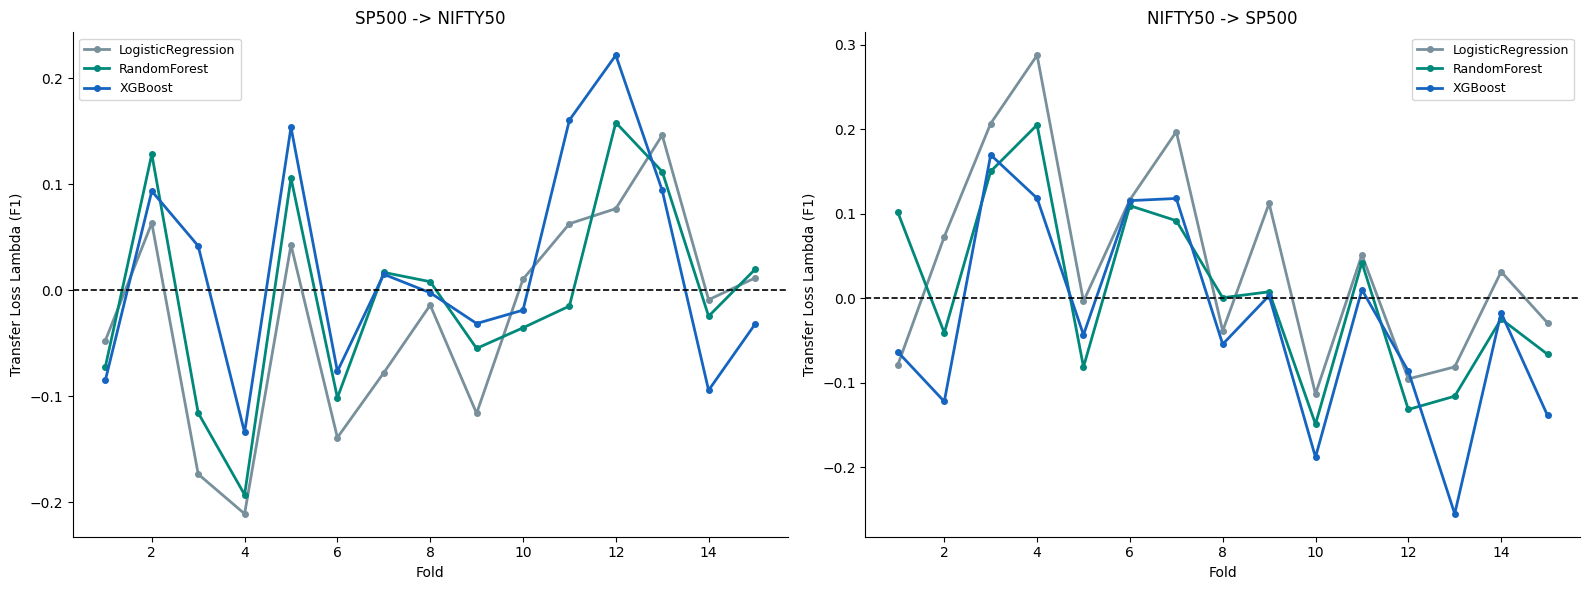

In [9]:
# Transfer loss plot

directions = transfer_all['Direction'].unique().tolist()
fig, axes  = plt.subplots(1, len(directions), figsize=(8 * len(directions), 6))
if len(directions) == 1:
    axes = [axes]

model_colors = {
    'LogisticRegression': '#78909c',
    'RandomForest'      : '#00897b',
    'XGBoost'           : '#1565c0',
}

for ax, direction in zip(axes, directions):
    df_d = transfer_all[transfer_all['Direction'] == direction]
    for model, color in model_colors.items():
        sub = df_d[df_d['Model'] == model].dropna(subset=['Lambda_F1']).sort_values('Fold')
        if sub.empty:
            continue
        ax.plot(sub['Fold'], sub['Lambda_F1'], label=model, color=color,
                linewidth=2, marker='o', markersize=4)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Transfer Loss Lambda (F1)')
    ax.set_title(direction.replace('->',' -> '))
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/06_transfer_loss_v2.png', dpi=150, bbox_inches='tight')
plt.show()

Features used for attribution: ['Log_Ret_t', 'Log_Ret_1', 'Log_Ret_5', 'Ret_Mean_5', 'RSI_5', 'Above_MA50', 'VIX_Level', 'Term_Spread', 'Gold_Ret', 'Gold_Oil_Ratio', 'FG_Delta', 'FG_Zone', 'SVI_Index', 'FG_x_SVI', 'Vol_Adj_Ret']

Attribution (SP500 model -> NIFTY 50):
Feature                      Local    Transfer     Delta
----------------------------------------------------------
Gold_Oil_Ratio             0.08744     0.06873  +0.01871  <- degraded
RSI_5                      0.08963     0.07140  +0.01824  <- degraded
VIX_Level                  0.13281     0.12453  +0.00827  <- degraded
Vol_Adj_Ret                0.03143     0.02713  +0.00431  <- degraded
Log_Ret_1                  0.03642     0.03280  +0.00362  <- degraded
Gold_Ret                   0.08304     0.07985  +0.00319  <- degraded
Above_MA50                 0.00035     0.00027  +0.00008  
FG_Zone                    0.00207     0.00253  -0.00045  <- improved
FG_x_SVI                   0.01150     0.01203  -0.00053  <- impro

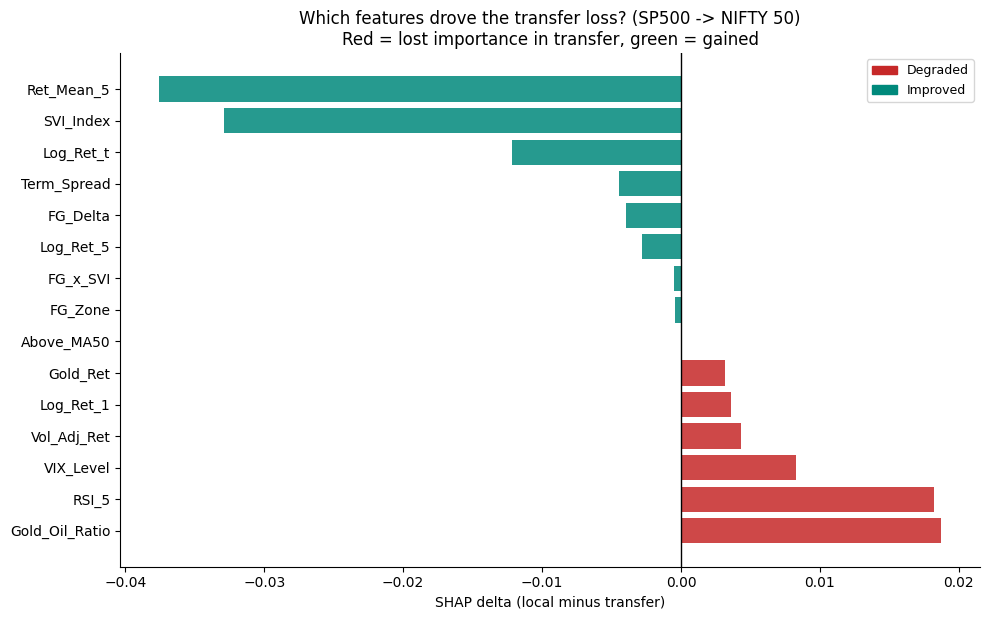

In [10]:
# SHAP attribution of transfer degradation
# Which features caused the loss when the SP500 model was applied to NIFTY?

common_transfer = [f for f in selected_sp500
                   if f in nifty.columns
                   and f not in NIFTY_ONLY
                   and f in selected_nifty]

if not common_transfer:
    # Broader fallback
    common_transfer = [f for f in selected_sp500
                       if f in nifty.columns and f not in NIFTY_ONLY]

print(f'Features used for attribution: {common_transfer}')

attr_df = pd.DataFrame()

if common_transfer and len(common_transfer) >= 2:
    tr_idx = windows_sp500[-1][0]
    te_sp  = windows_sp500[-1][2]
    te_ni  = windows_nifty[-1][2]

    X_sp_tr  = sp500.loc[tr_idx, common_transfer].fillna(0)
    y_sp_tr  = sp500.loc[tr_idx, TARGET]
    X_sp_te  = sp500.loc[te_sp,  common_transfer].fillna(0)
    X_ni_te  = nifty.loc[te_ni,  common_transfer].fillna(0)

    m_attr = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', random_state=SEED, verbosity=0
    )
    m_attr.fit(X_sp_tr, y_sp_tr)

    exp_attr   = shap.TreeExplainer(m_attr)
    shap_local  = exp_attr.shap_values(X_sp_te)
    shap_transf = exp_attr.shap_values(X_ni_te)

    local_mean  = pd.Series(np.abs(shap_local).mean(axis=0),  index=common_transfer)
    transf_mean = pd.Series(np.abs(shap_transf).mean(axis=0), index=common_transfer)

    attr_df = pd.DataFrame({
        'SHAP_local'   : local_mean,
        'SHAP_transfer': transf_mean,
        'SHAP_delta'   : local_mean - transf_mean,
    }).sort_values('SHAP_delta', ascending=False)

    print('\nAttribution (SP500 model -> NIFTY 50):')
    print(f'{"Feature":22}  {"Local":>10}  {"Transfer":>10}  {"Delta":>8}')
    print('-' * 58)
    for feat, row in attr_df.iterrows():
        note = '<- degraded' if row['SHAP_delta'] > 0.0001 else '<- improved' if row['SHAP_delta'] < -0.0001 else ''
        print(f'{feat:22}  {row["SHAP_local"]:10.5f}  {row["SHAP_transfer"]:10.5f}  {row["SHAP_delta"]:+8.5f}  {note}')

    # Attribution bar chart
    fig, ax = plt.subplots(figsize=(10, max(4, len(attr_df) * 0.42)))
    colors  = ['#c62828' if v > 0 else '#00897b' for v in attr_df['SHAP_delta']]
    ax.barh(attr_df.index, attr_df['SHAP_delta'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('SHAP delta (local minus transfer)')
    ax.set_title('Which features drove the transfer loss? (SP500 -> NIFTY 50)\n'
                 'Red = lost importance in transfer, green = gained')
    red_p   = mpatches.Patch(color='#c62828', label='Degraded')
    green_p = mpatches.Patch(color='#00897b', label='Improved')
    ax.legend(handles=[red_p, green_p], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{PLOTS}/06_shap_transfer_attribution_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough common features for attribution. '
          'Check that both markets have overlapping selected features.')

In [11]:
# Save all results

pd.DataFrame([h3_result]).to_csv(f'{RESULTS}/h3_test_results.csv', index=False)
h4_df.to_csv(f'{RESULTS}/h4_test_results.csv', index=False)
transfer_all.to_csv(f'{RESULTS}/transfer_results.csv', index=False)

if not attr_df.empty:
    attr_df.to_csv(f'{RESULTS}/shap_transfer_attribution.csv')

shap_mean_sp500.to_csv(f'{RESULTS}/shap_importance_sp500.csv', header=['mean_abs_shap'])
shap_mean_nifty.to_csv(f'{RESULTS}/shap_importance_nifty.csv', header=['mean_abs_shap'])

print('Saved to data/results/')

Saved to data/results/


In [12]:
# Final summary — all four hypotheses

try:
    h1_df = pd.read_csv(f'{RESULTS}/h1_test_results.csv')
except FileNotFoundError:
    h1_df = pd.DataFrame()

try:
    h2_df = pd.read_csv(f'{SELECTED}/h2_test_results.csv')
except FileNotFoundError:
    h2_df = pd.DataFrame()

print('=' * 65)
print('  CAPSTONE RESULTS — ALL HYPOTHESIS TESTS')
print('=' * 65)

if not h1_df.empty:
    print('\nH1 — Signal efficacy (alt-data AUC vs baseline)')
    for _, row in h1_df.iterrows():
        print(f"  {row.get('Market','?'):12} | {row.get('Model','?'):22} | "
              f"delta={row.get('Mean_Delta_AUC','?'):+.4f} | "
              f"p={row.get('p_one_tail','?'):.4f} | {row.get('Result','?')}")

if not h2_df.empty:
    print('\nH2 — Feature stability (Jaccard: alt-data vs technicals)')
    for _, row in h2_df.iterrows():
        result = 'Alt-data less stable' if row.get('Reject_H0') else 'No significant difference'
        print(f"  {row.get('Market','?'):12} | J(alt)={row.get('Mean_J_alt','?'):.3f} "
              f"J(tech)={row.get('Mean_J_tech','?'):.3f} | p={row.get('p_one_tail','?'):.4f} | {result}")

if h3_result:
    print('\nH3 — SVI structural divergence (NIFTY vs SP500 SHAP)')
    print(f"  SVI SHAP SP500  : {h3_result.get('Mean_SVI_SHAP_SP500','?'):.6f}")
    print(f"  SVI SHAP NIFTY  : {h3_result.get('Mean_SVI_SHAP_NIFTY','?'):.6f}")
    print(f"  p (one-tail)    : {h3_result.get('p_one_tail','?'):.4f}")
    result = 'SVI more important in NIFTY' if h3_result.get('Reject_H0') else 'No significant difference'
    print(f"  Result          : {result}")
    if h3_result.get('Spearman_r') is not None:
        print(f"  Spearman r      : {h3_result['Spearman_r']:.3f}")

if not h4_df.empty:
    print('\nH4 — Transfer Loss Lambda = F1_local - F1_transfer')
    for _, row in h4_df.iterrows():
        print(f"  {str(row.get('Direction','?')):25} | {row.get('Model','?'):22} | "
              f"Lambda={row.get('Mean_Lambda_F1','?'):+.4f} | "
              f"p={row.get('p_one_tail','?'):.4f} | {row.get('Result','?')}")

print('\n' + '=' * 65)

  CAPSTONE RESULTS — ALL HYPOTHESIS TESTS

H1 — Signal efficacy (alt-data AUC vs baseline)
  S&P 500      | LogisticRegression     | delta=+0.0176 | p=0.1745 | No significant gain
  S&P 500      | RandomForest           | delta=+0.0071 | p=0.3740 | No significant gain
  S&P 500      | XGBoost                | delta=+0.0136 | p=0.3301 | No significant gain
  NIFTY 50     | LogisticRegression     | delta=-0.0509 | p=0.9711 | No significant gain
  NIFTY 50     | RandomForest           | delta=-0.0043 | p=0.6241 | No significant gain
  NIFTY 50     | XGBoost                | delta=-0.0227 | p=0.9447 | No significant gain

H2 — Feature stability (Jaccard: alt-data vs technicals)
  S&P 500      | J(alt)=0.804 J(tech)=0.747 | p=0.7402 | No significant difference
  NIFTY 50     | J(alt)=0.839 J(tech)=0.731 | p=0.9047 | No significant difference

H3 — SVI structural divergence (NIFTY vs SP500 SHAP)
  SVI SHAP SP500  : 0.057993
  SVI SHAP NIFTY  : 0.092430
  p (one-tail)    : 0.0000
  Result    